## imports

In [1]:
import logging
import os
import random

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import umap
from dataclasses import asdict
from torch.utils.data import DataLoader

from utils import (
    load_patient_ids, pad_ucsf_ids, build_id_to_cohort, TDMapDataset,
    split_ids, save_splits, load_splits,
    build_dataset_from_ids,
    compute_bounding_box, bbox_to_padded_shape,
    compute_normalisation_stats, load_brain_mask,
    save_preprocessing_stats,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

from dotenv import load_dotenv
load_dotenv()

import wandb

## config

In [2]:
from config import Config

cfg = Config()
print(f"Device: {cfg.device}")

Device: cuda


In [4]:
print(f""" 
Patience: {cfg.patience} 
Latent size: {cfg.latent_dim}""")

 
Patience: 20 
Latent size: 4


## what are the volumes?

Template shape : (131, 155, 126)
Brain mask shape: (131, 155, 126)


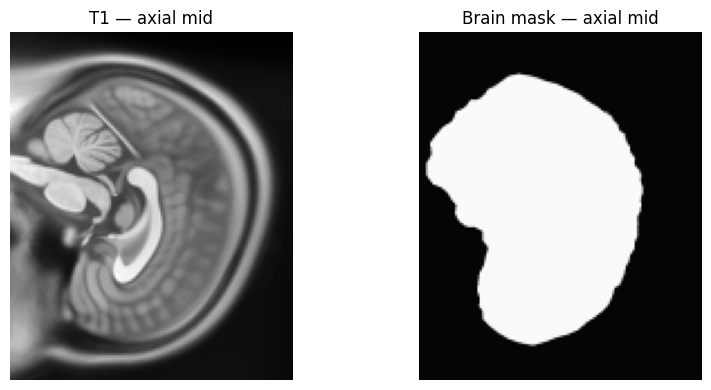

In [5]:
t1      = nib.load(cfg.template)
t1_mask = nib.load(cfg.brain_mask)

print(f"Template shape : {t1.shape}")
print(f"Brain mask shape: {t1_mask.shape}")

mid = t1.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(t1.get_fdata()[mid],      cmap="gray");  axes[0].set_title("T1 — axial mid")
axes[1].imshow(t1_mask.get_fdata()[mid], cmap="gray");  axes[1].set_title("Brain mask — axial mid")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## load patient IDs from demographic CSVs

In [6]:
# NOTE: There are commentable ifs in the load_patient_ids function in utils.py
# allowing to load data that has survival data missing but can be used for unsupervised training
patient_ids = load_patient_ids(cfg.gbm_root, cfg.cohort_dirs)
patient_ids["ucsf"] = pad_ucsf_ids(patient_ids["ucsf"])

print("\nSample UCSF IDs:", patient_ids["ucsf"][:5])

  UCSF     —  368 subjects  (CSV: (368, 27))
  UPENN    —  496 subjects  (CSV: (496, 18))
  RHUH     —   34 subjects  (CSV: (34, 33))
  TCGA     —  103 subjects  (CSV: (103, 22))

  Total: 1001 subjects across 4 cohorts

Sample UCSF IDs: ['UCSF-PDGM-0009', 'UCSF-PDGM-0004', 'UCSF-PDGM-0008', 'UCSF-PDGM-0011', 'UCSF-PDGM-0014']


## just exploring datasets

In [6]:
def load_cohort_csv(root: str, cohort_dir: str):
    csv_path = f"{root}/{cohort_dir}/demographics-TDMaps_streamTH-0.csv"
    return pd.read_csv(csv_path)


upenn_csv = load_cohort_csv(cfg.gbm_root, cfg.cohort_dirs["upenn"])
ucsf_csv  = load_cohort_csv(cfg.gbm_root, cfg.cohort_dirs["ucsf"])
rhuh_csv  = load_cohort_csv(cfg.gbm_root, cfg.cohort_dirs["rhuh"])
tcga_csv  = load_cohort_csv(cfg.gbm_root, cfg.cohort_dirs["tcga"])

In [7]:
print(upenn_csv.columns) # all ok? check survival status - ok
print("\n", ucsf_csv.columns) # choose wildtype only
print("\n", rhuh_csv.columns) # previus treatment must be no, does "right censored" play the role of dead/alive
print("\n", tcga_csv.columns) # all ok

Index(['ID', 'Gender', 'Age_at_scan_years',
       'Survival_from_surgery_days_UPDATED', 'Survival_Status', 'MGMT', 'KPS',
       'GTR_over90percent', 'Whole TDMap', 'Whole lesion TDMap', 'Core TDMap',
       'Core lesion TDMap', 'Non-enhancing TDMap',
       'Non-enhancing lesion TDMap', 'Enhancing TDMap',
       'Enhancing lesion TDMap', 'Core+Enhancing TDMap',
       'Core+Enhancing lesion TDMap'],
      dtype='str')

 Index(['ID', 'Sex', 'Age at MRI', 'WHO CNS Grade',
       'Final pathologic diagnosis (WHO 2021)', 'MGMT status', 'MGMT index',
       '1p/19q', 'IDH', '1-dead 0-alive', 'OS', 'EOR',
       'Biopsy prior to imaging', 'BraTS21 ID', 'BraTS21 Segmentation Cohort',
       'BraTS21 MGMT Cohort', '# Labels', 'Whole TDMap', 'Whole lesion TDMap',
       'Core TDMap', 'Core lesion TDMap', 'Non-enhancing TDMap',
       'Non-enhancing lesion TDMap', 'Enhancing TDMap',
       'Enhancing lesion TDMap', 'Core+Enhancing TDMap',
       'Core+Enhancing lesion TDMap'],
      dtype='str

In [8]:
print((upenn_csv["Survival_from_surgery_days_UPDATED"].isnull() == True).sum())

0


In [9]:
print(((ucsf_csv["OS"]).isnull() == True).sum())
# print((ucsf_csv["1-dead 0-alive"] == 1).sum())


1


In [10]:
print((ucsf_csv["Final pathologic diagnosis (WHO 2021)"].str.contains("wildtype")).sum())

368


In [11]:
print(rhuh_csv["Previous treatment"].str.contains("no").sum())

34


In [12]:
print((tcga_csv["Vital.status..1.dead."] == 0.0).sum())
print((tcga_csv["Vital.status..1.dead."] == 1.0).sum())

21
82


## train / val / test split (DONT RUN FOR INFERENCE)

In [7]:
splits = split_ids(                                                           
    patient_ids   = patient_ids,
    strategy      = cfg.split_strategy, # either stratified or cohort holdout - specified in config.py  
    test_cohorts  = cfg.test_cohorts,                                         
    test_fraction = cfg.test_fraction,
    val_fraction  = cfg.val_fraction,                                         
    seed          = cfg.random_seed,                                          
)      

print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

save_splits(splits, cfg.splits_dir)
print(f"Split files saved to: {cfg.splits_dir}")

INFO | Split [stratified] → train: 725 | val: 127 | test: 149
INFO | Saved 725 IDs -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/splits/train_ids.txt
INFO | Saved 127 IDs -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/splits/val_ids.txt
INFO | Saved 149 IDs -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/splits/test_ids.txt


Train: 725 | Val: 127 | Test: 149
Split files saved to: /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/splits


In [8]:
# load splits if already split
splits = load_splits(cfg.splits_dir)

## preprocessing, datasets, and dataloaders

In [9]:
bbox         = compute_bounding_box(cfg.brain_mask)
padded_shape = bbox_to_padded_shape(bbox)

print(f"Bbox        : {bbox}")
print(f"Padded shape: {padded_shape}  (each dim divisible by powers of two)")

Bbox        : {'z_min': 16, 'z_max': 115, 'y_min': 16, 'y_max': 140, 'x_min': 3, 'x_max': 104}
Padded shape: (112, 128, 112)  (each dim divisible by powers of two)


#### TODO (maybe someday)
This could potentialy be rewritten so that it's cleaner - done in utils not here bcs the normalization argument in the build_dataset_from_ids is kind of useless - just used for the saving which also doesn't currently happen if norm is none and should for the cropping maybe

In [10]:
# Z-score stats are only needed when normalisation involves zscore.
# Stats are computed on the pre-zscore representation (no padding so zeros don't skew mean/std).
brain_mask = load_brain_mask(cfg.brain_mask, bbox, padded_shape)
id_to_cohort = build_id_to_cohort(patient_ids)

if cfg.normalisation in ("zscore", "log1p_zscore"):
    pre_norm   = "log1p" if cfg.normalisation == "log1p_zscore" else "none"
    stats_ds   = build_dataset_from_ids(splits["train"], id_to_cohort, cfg,
                                        bbox=bbox, padded_shape=padded_shape,
                                        normalisation=pre_norm, brain_mask=brain_mask)
    norm_stats = compute_normalisation_stats(stats_ds, mask=brain_mask)
    nm, ns     = norm_stats["mean"], norm_stats["std"]

else:
    nm, ns = None, None

save_preprocessing_stats(bbox, padded_shape, nm, ns, cfg.preprocessing_path)

INFO | Normalisation stats — mean: 15.9403  std: 65.3403  (n_voxels: 434351125)
INFO | Saved preprocessing stats -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/preprocessing_stats.json


In [21]:
import json

json.dump(id_to_cohort, open(f"{cfg.root}/id_to_cohort.json", "w"))

In [11]:
train_dataset = build_dataset_from_ids(splits["train"], id_to_cohort, cfg,
                                       bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask=brain_mask)
val_dataset   = build_dataset_from_ids(splits["val"],   id_to_cohort, cfg,
                                       bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask=brain_mask)
test_dataset  = build_dataset_from_ids(splits["test"],  id_to_cohort, cfg,
                                       bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask=brain_mask)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

batch = next(iter(train_loader))
print(f"Preprocessed batch shape: {batch.shape}")

# TODO: fix comment?
assert all(s % 16 == 0 for s in batch.shape[2:]), "Spatial dims not divisible by 16 — check padded_shape"

Preprocessed batch shape: torch.Size([4, 1, 112, 128, 112])


Shape  : torch.Size([1, 112, 128, 112])
Min    : -0.2440
Max    : 12.3424
Mean   : -0.1744
NaNs   : 0
Nonzero: 1605632 / 1605632 voxels


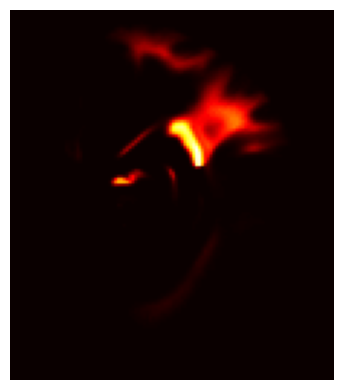

In [13]:
# Sanity check: inspect one training volume before committing to a training run
vol = train_dataset[0]
print(f"Shape  : {vol.shape}")
print(f"Min    : {vol.min():.4f}")
print(f"Max    : {vol.max():.4f}")
print(f"Mean   : {vol.mean():.4f}")
print(f"NaNs   : {torch.isnan(vol).sum().item()}")
print(f"Nonzero: {(vol != 0).sum().item()} / {vol.numel()} voxels")

mid = vol.shape[1] // 3
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(vol[0, mid].numpy(), cmap="hot")
ax.axis("off")
plt.tight_layout()
plt.show()

## Model + Training

In [14]:
from model import Autoencoder
from train import train

brain_mask = load_brain_mask(cfg.brain_mask, bbox, padded_shape).to(cfg.device)
model      = Autoencoder(
    input_shape=padded_shape,
    latent_dim=cfg.latent_dim,
    # channels=cfg.encoder_channels,
).to(cfg.device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters : {n_params:,}")
# print(f"Input shape: {padded_shape}   latent_dim={cfg.latent_dim}   channels={cfg.encoder_channels}")
print(f"Input shape: {padded_shape}   latent_dim={cfg.latent_dim}")

wandb.init(
    project=cfg.wandb_project,
    config={
        **asdict(cfg),
        "input_shape": list(padded_shape),
        "n_params":    n_params,
    },
)

history = train(
    model           = model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    # brain_mask      = brain_mask,
    device          = cfg.device,
    save_path       = cfg.save_path,
    epochs          = cfg.epochs,
    lr              = cfg.lr,
    weight_decay    = cfg.weight_decay,
    patience        = cfg.patience,
    recon_dataset   = test_dataset,
    log_image_every = 10,
)

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Parameters : 371,733
Input shape: (112, 128, 112)   latent_dim=4


wandb: Currently logged in as: rybska-julia (julia-rybska-agh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


INFO | Epoch   0 | train 0.4517 | val 0.3187
INFO | Epoch  10 | train 0.0807 | val 0.0677
INFO | Epoch  20 | train 0.0640 | val 0.0535
INFO | Epoch  30 | train 0.0543 | val 0.0469
INFO | Epoch  40 | train 0.0487 | val 0.0450
INFO | Epoch  50 | train 0.0448 | val 0.0414
INFO | Epoch  60 | train 0.0428 | val 0.0406
INFO | Epoch  70 | train 0.0403 | val 0.0421
INFO | Epoch  80 | train 0.0389 | val 0.0403
INFO | Epoch  90 | train 0.0376 | val 0.0365
INFO | Epoch 100 | train 0.0361 | val 0.0350
INFO | Epoch 110 | train 0.0351 | val 0.0351
INFO | Epoch 120 | train 0.0344 | val 0.0352
INFO | Epoch 130 | train 0.0337 | val 0.0347
INFO | Epoch 140 | train 0.0330 | val 0.0352
INFO | Epoch 150 | train 0.0321 | val 0.0340
INFO | Epoch 160 | train 0.0317 | val 0.0338
INFO | Epoch 170 | train 0.0313 | val 0.0337
INFO | Epoch 180 | train 0.0308 | val 0.0327
INFO | Epoch 190 | train 0.0308 | val 0.0319
INFO | Epoch 200 | train 0.0301 | val 0.0317
INFO | Epoch 210 | train 0.0296 | val 0.0331
INFO | Epo

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇████
lr,██████▇▇▇▇▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▂▁▁▁▁▁
train_loss,█▅▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_loss,0.03144
epoch,224
lr,1e-05
train_loss,0.02964
val_loss,0.03238


## Analysis

In [16]:
from model import Autoencoder

model      = Autoencoder(
    input_shape=padded_shape,
    latent_dim=cfg.latent_dim,
    # channels=cfg.encoder_channels,
).to(cfg.device)

model.load_state_dict(torch.load(cfg.save_path, map_location=cfg.device))
model.eval()
print("Model loaded.")

Model loaded.


In [17]:
splits = load_splits(cfg.splits_dir)

### Reconstructions

Pick a few subjects and compare input vs reconstruction slice by slice.
If tract patterns are visible in the reconstruction column, the model has learned something real.

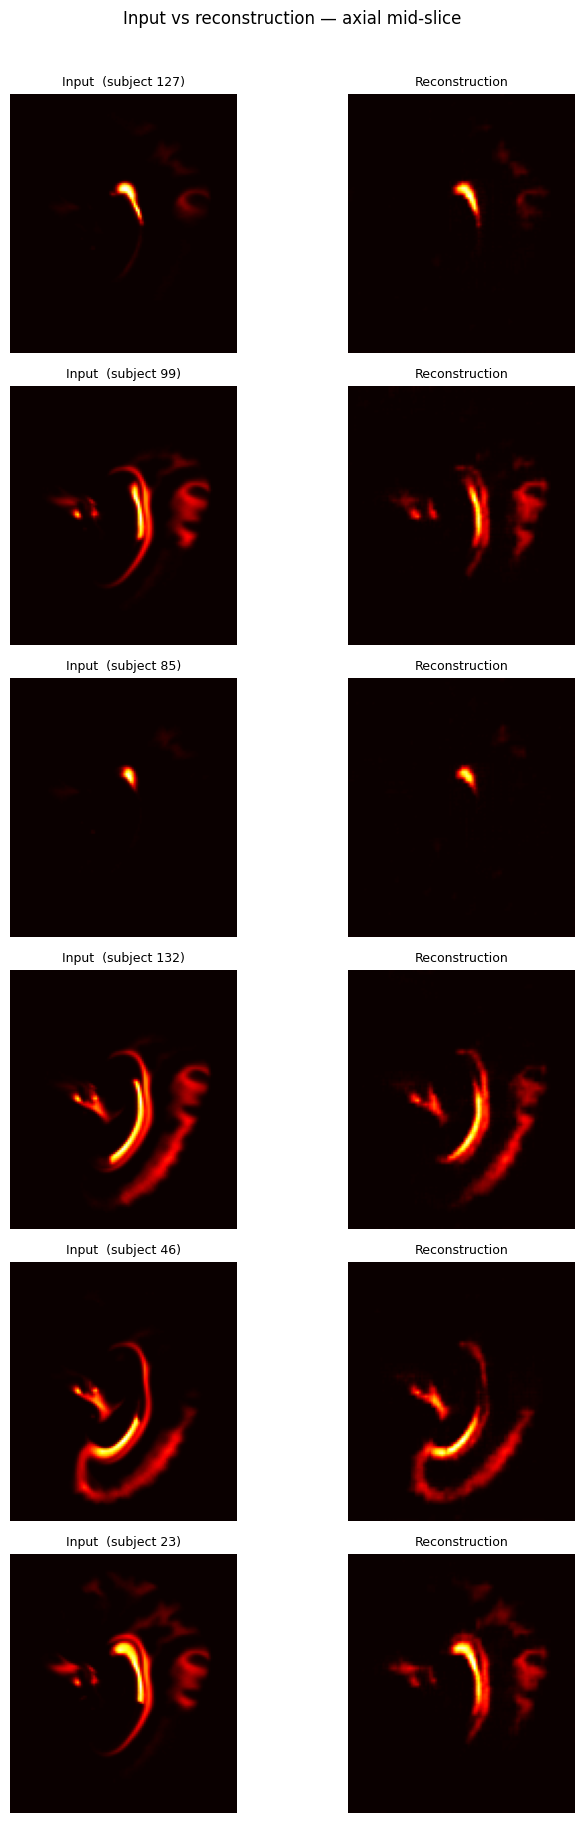

In [18]:
N_EXAMPLES = 6
indices = random.sample(range(len(test_dataset)), N_EXAMPLES)

fig, axes = plt.subplots(N_EXAMPLES, 2, figsize=(8, N_EXAMPLES * 3))

model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        vol   = test_dataset[idx].unsqueeze(0).to(cfg.device)  # (1, 1, D, H, W)
        recon, _ = model(vol)

        mid = vol.shape[2] // 2  # axial mid-slice
        inp = vol  [0, 0, mid].cpu().numpy()
        rec = recon[0, 0, mid].cpu().numpy()

        vmin, vmax = inp.min(), inp.max()

        axes[row, 0].imshow(inp, cmap="hot", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"Input  (subject {idx})", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(rec, cmap="hot", vmin=vmin, vmax=vmax)
        axes[row, 1].set_title("Reconstruction", fontsize=9)
        axes[row, 1].axis("off")

plt.suptitle("Input vs reconstruction — axial mid-slice", y=1.01)
plt.tight_layout()
plt.show()

### Encode all subjects + save

In [19]:
from train import encode_dataset

all_ids     = splits["train"] + splits["val"] + splits["test"]
# all_ids = np.load(os.path.join(cfg.root, "latent_codes_ids.npy"), allow_pickle=True).tolist()
all_dataset = build_dataset_from_ids(all_ids, id_to_cohort, cfg, bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask)
all_loader  = DataLoader(all_dataset, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers, pin_memory=True)

codes = encode_dataset(model, all_loader, cfg.device)
print(f"Latent codes: {codes.shape}")

np.save(os.path.join(cfg.root, "latent_codes.npy"),     codes.numpy())
np.save(os.path.join(cfg.root, "latent_codes_ids.npy"), np.array(all_ids))
print("Saved.")

Latent codes: torch.Size([1001, 4])
Saved.


### Latent space visualisation

torch.Size([1001, 4])
1001


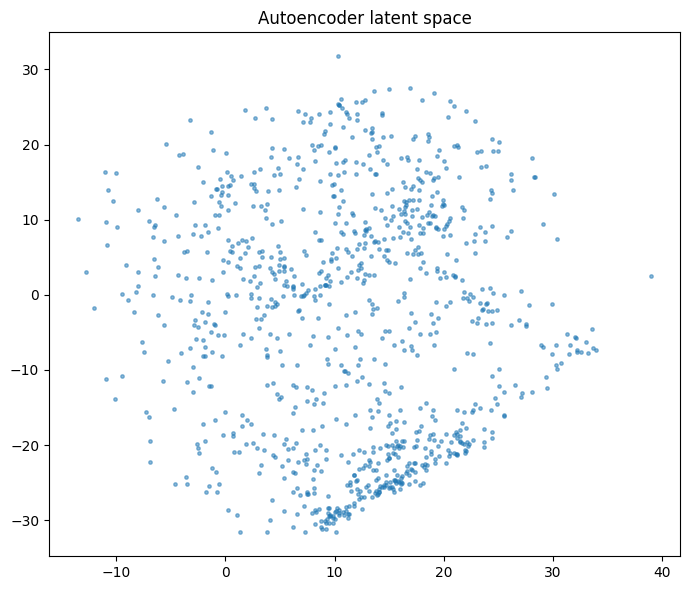

In [20]:
codes   = torch.tensor(np.load(os.path.join(cfg.root, "latent_codes.npy")))
all_ids = np.load(os.path.join(cfg.root, "latent_codes_ids.npy"), allow_pickle=True).tolist()

print(codes.shape)
print(len(all_ids))

plt.figure(figsize=(7, 6))
plt.scatter(codes[:, 0], codes[:, 1], s=6, alpha=0.5)
plt.title("Autoencoder latent space")
plt.tight_layout()
plt.savefig(os.path.join(cfg.root, "latent_space.png"), dpi=150)
plt.show()

### Latent space coloured by survival

In [19]:
codes     = torch.tensor(np.load(os.path.join(cfg.root, "latent_codes.npy")))
all_ids   = np.load(os.path.join(cfg.root, "latent_codes_ids.npy"), allow_pickle=True).tolist()
# embedding = np.load(os.path.join(cfg.root, "umap_embedding.npy"))

clinical = pd.read_csv(cfg.clinical_csv, index_col=0)
clinical.index = clinical.index.map(
    lambda sid: "-".join(sid.strip().split("-")[:-1] + [sid.strip().split("-")[-1].zfill(4)])
)

os_days = np.array([
    clinical.loc[sid, "OS (days) - corrected"] if sid in clinical.index else np.nan
    for sid in all_ids
])
status = np.array([
    clinical.loc[sid, "status"] if sid in clinical.index else np.nan
    for sid in all_ids
])

print(f"Subjects found in CSV : {(~np.isnan(os_days)).sum()} / {len(all_ids)}")
print(f"Dead: {(status == 1).sum()}  |  Censored: {(status == 0).sum()}  |  Missing: {np.isnan(status).sum()}")

Subjects found in CSV : 999 / 1001
Dead: 811  |  Censored: 188  |  Missing: 2


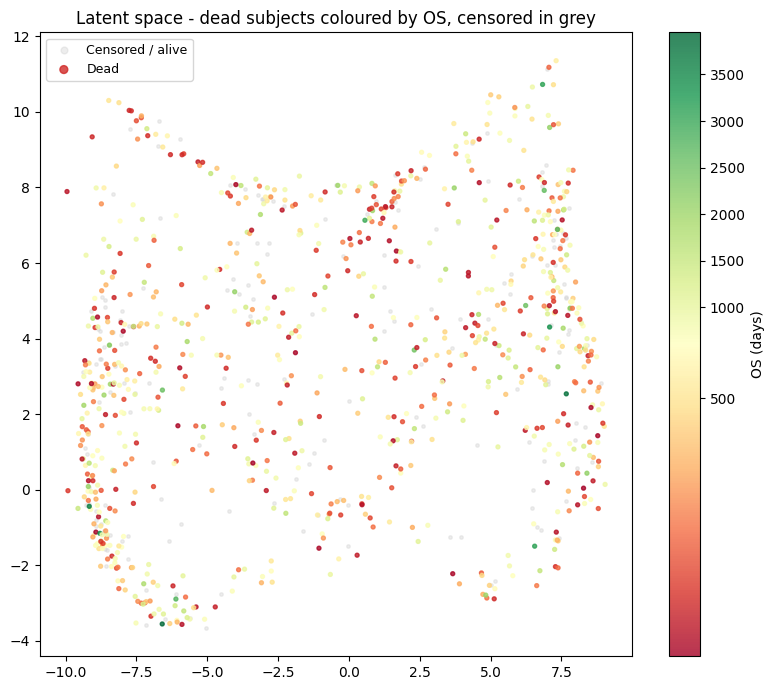

In [20]:
from matplotlib.colors import TwoSlopeNorm                                    

dead_mask     = status == 1                                                   
censored_mask = status == 0
                                                                            
dead_os = os_days[dead_mask]
norm = TwoSlopeNorm(vcenter=dead_os.mean(), vmin=dead_os.min(),               
vmax=dead_os.max())                                                           

fig, ax = plt.subplots(figsize=(8, 7))                                        
                
ax.scatter(
    codes[censored_mask, 0], codes[censored_mask, 1],
    s=6, c="lightgrey", alpha=0.4, label="Censored / alive"                   
)
                                                                            
sc = ax.scatter(
    codes[dead_mask, 0], codes[dead_mask, 1],
    s=8, c=dead_os, cmap="RdYlGn", norm=norm,                                 
    alpha=0.8, label="Dead"
)                                                                             
                
plt.colorbar(sc, ax=ax, label="OS (days)")                                    
ax.set_title("Latent space - dead subjects coloured by OS, censored in grey")                                                      
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()                                                            
# plt.savefig(os.path.join(ROOT, "umap_survival.png"), dpi=150)
plt.show()              